# Formative Assignment: Advanced Linear Algebra (PCA)





# Formative Assignment: Advanced Linear Algebra (PCA)
This notebook implements **Principal Component Analysis** on an Africanized
dataset: monthly rainfall observations for Rwanda (HDX HAPI).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

In [ ]:
CSV_PATH = "/content/drive/MyDrive/hdx_hapi_rainfall_rwa.csv"

with open(CSV_PATH) as f:
    header = f.readline().strip().split(",")

raw = np.genfromtxt(CSV_PATH, delimiter=",", skip_header=1,
                    dtype=str, encoding="utf-8", autostrip=True)

# 7 features: 2 non-numeric (aggregation_period, version) + 5 numeric
selected_columns = [
    'aggregation_period', 'version', 'provider_admin1_code',
    'rainfall', 'rainfall_long_term_average',
    'rainfall_anomaly_pct', 'number_pixels',
]

data = raw[:, [header.index(c) for c in selected_columns]]
print("Selected data shape:", data.shape)
print("Sample row:", data[0])

Selected data shape: (2385, 7)
Sample row: ['dekad' 'final' '900110' '10.869565' '22.782608' '57.120502' '23']


### Step 2: Fill missing values and encode text columns
Numeric columns are imputed with the column **mean**; non-numeric columns with the
column **mode**, then label-encoded with `pd.factorize`. Column types are detected
from the data.


In [ ]:
n, p  = data.shape
X_raw = np.empty((n, p))
encodings = {}

for j, name in enumerate(selected_columns):
    col  = data[:, j]
    miss = np.isin(np.char.lower(col), ["", "nan", "na", "null"])   # find missing entries

    probe = col.astype("U64"); probe[miss] = "nan"                  # widen to avoid truncation
    try:                                                            # numeric column
        vals = probe.astype(float)
        vals[np.isnan(vals)] = np.nanmean(vals)                     # mean imputation
        X_raw[:, j] = vals
    except ValueError:                                              # categorical column
        classes, counts = np.unique(col[~miss], return_counts=True)
        col = col.copy(); col[miss] = classes[np.argmax(counts)]    # mode imputation
        # label-encode in order of first appearance
        uniq, first_idx, inverse = np.unique(col, return_index=True, return_inverse=True)
        order = np.argsort(first_idx)
        rank  = np.empty(len(order), dtype=int); rank[order] = np.arange(len(order))
        X_raw[:, j]     = rank[inverse]
        encodings[name] = dict(enumerate(uniq[order]))

print("Encodings:", encodings)
print("NaNs remaining:", int(np.isnan(X_raw).sum()))
print("Feature matrix:", X_raw.shape)


Encodings: {'aggregation_period': {0: np.str_('dekad'), 1: np.str_('1-month'), 2: np.str_('3-month')}, 'version': {0: np.str_('final'), 1: np.str_('preliminary'), 2: np.str_('forecast')}}
NaNs remaining: 0
Feature matrix: (2385, 7)


In [ ]:
def standardize(X):
    """Column-wise mean 0 / unit variance. Guards against zero-variance columns."""
    mean = X.mean(axis=0)
    std  = X.std(axis=0)
    std  = np.where(std == 0, 1.0, std)      # avoid division by zero
    return (X - mean) / std

X_std = standardize(X_raw)
print("Standardized shape:", X_std.shape)
print(np.round(X_std[:5], 3))

Standardized shape: (2385, 7)
[[-1.225 -0.131 -1.414 -0.938 -0.899 -1.149 -1.431]
 [ 0.    -0.131 -1.414 -0.301 -0.436  0.52  -1.431]
 [ 1.225 -0.131 -1.414  1.217  1.395 -0.061 -1.431]
 [-1.225 -0.131 -1.414 -0.706 -0.908  2.134 -1.431]
 [ 0.    -0.131 -1.414 -0.249 -0.46   0.863 -1.431]]


### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other.

In [ ]:
cov_matrix = (X_std.T @ X_std) / (X_std.shape[0] - 1)
print("Covariance matrix shape:", cov_matrix.shape)
np.round(cov_matrix, 3)

Covariance matrix shape: (7, 7)


array([[ 1.   ,  0.   ,  0.   ,  0.766,  0.809,  0.012, -0.   ],
       [ 0.   ,  1.   , -0.   ,  0.014,  0.055, -0.113, -0.   ],
       [ 0.   , -0.   ,  1.   ,  0.108,  0.098,  0.046,  0.304],
       [ 0.766,  0.014,  0.108,  1.   ,  0.955,  0.26 , -0.011],
       [ 0.809,  0.055,  0.098,  0.955,  1.   ,  0.057, -0.017],
       [ 0.012, -0.113,  0.046,  0.26 ,  0.057,  1.   ,  0.003],
       [-0.   , -0.   ,  0.304, -0.011, -0.017,  0.003,  1.   ]])

We compute the covariance matrix for two main reasons. First, it measures the linear relationship between every pair of features at once(shows whether two variables increase together or move in opposite directions), which is the structure PCA uses to find the directions of greatest variance. Second, it condenses all of this information into one compact symmetric matrix (7x7 here) whose eigenvectors directly give the principal component directions.

### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors.

In [ ]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
print("Eigenvalues:", np.round(eigenvalues, 4))
eigenvectors

Eigenvalues: [0.0228 0.2365 0.6962 0.8964 1.1225 1.3066 2.7219]


array([[-0.04192215,  0.80433286, -0.11057812,  0.18007068,  0.09388749,
         0.08720874,  0.53871884],
       [-0.01336338,  0.05773985, -0.0546827 , -0.72413204,  0.68282359,
         0.05115336,  0.01629115],
       [-0.00180652,  0.12194995,  0.69748173, -0.0326635 ,  0.06144568,
        -0.69877373,  0.07427633],
       [-0.69341158, -0.40426102,  0.01009436, -0.0724502 , -0.06951678,
         0.00107626,  0.58785095],
       [ 0.70503544, -0.37902773,  0.03401025,  0.05544672,  0.09081008,
         0.03386232,  0.58791057],
       [ 0.1419521 ,  0.15407372, -0.12918983, -0.64799438, -0.70136463,
        -0.12179743,  0.11303627],
       [ 0.00396281, -0.0633661 , -0.69307497,  0.11798453,  0.12716175,
        -0.69678606,  0.00385363]])

### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.

PC1:  38.87%  (cumulative  38.87%)
PC2:  18.66%  (cumulative  57.53%)
PC3:  16.03%  (cumulative  73.55%)
PC4:  12.80%  (cumulative  86.35%)
PC5:   9.94%  (cumulative  96.30%)
PC6:   3.38%  (cumulative  99.67%)
PC7:   0.33%  (cumulative 100.00%)


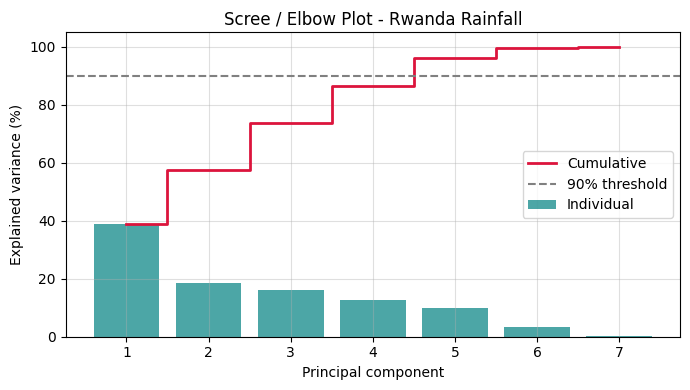

In [ ]:
order               = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues  = eigenvalues[order]
sorted_eigenvectors = eigenvectors[:, order]

explained_variance_ratio = sorted_eigenvalues / sorted_eigenvalues.sum()
cumulative_variance      = np.cumsum(explained_variance_ratio)

for i, (e, c) in enumerate(zip(explained_variance_ratio, cumulative_variance), start=1):
    print(f"PC{i}: {e*100:6.2f}%  (cumulative {c*100:6.2f}%)")

# Scree / elbow plot to justify how many components to keep
x = np.arange(1, len(sorted_eigenvalues) + 1)
plt.figure(figsize=(7, 4))
plt.bar(x, explained_variance_ratio * 100, alpha=0.7, color='teal', label='Individual')
plt.step(x, cumulative_variance * 100, where='mid', color='crimson', lw=2, label='Cumulative')
plt.axhline(90, color='gray', ls='--', label='90% threshold')
plt.title("Scree / Elbow Plot - Rwanda Rainfall")
plt.xlabel("Principal component"); plt.ylabel("Explained variance (%)")
plt.xticks(x); plt.legend(); plt.grid(alpha=0.4)
plt.tight_layout(); plt.show()

### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [ ]:
variance_target = 0.90
num_components  = int(np.argmax(cumulative_variance >= variance_target)) + 1
print(f"Components chosen: {num_components} "
      f"({cumulative_variance[num_components-1]*100:.1f}% of variance retained)")

W            = sorted_eigenvectors[:, :num_components]
reduced_data = X_std @ W
reduced_data[:5]

Components chosen: 5 (96.3% of variance retained)


array([[-1.98206765,  1.98038826,  0.3161446 ,  0.51380689,  0.25643684],
       [-0.48714571,  1.90034731, -0.7412719 , -0.367246  , -0.07236111],
       [ 2.07545793,  2.14158606, -0.15783924,  0.22150877, -0.05511274],
       [-1.48036664,  1.58048746, -2.00322948, -1.63071776, -0.1656474 ],
       [-0.43199701,  1.85772533, -0.98812208, -0.59505289, -0.11706018]])

### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [ ]:
variance_target = 0.90
num_components  = int(np.argmax(cumulative_variance >= variance_target)) + 1
print(f"Components chosen: {num_components} "
      f"({cumulative_variance[num_components-1]*100:.1f}% of variance retained)")

W            = sorted_eigenvectors[:, :num_components]
reduced_data = X_std @ W
np.round(reduced_data[:5], 3)

Components chosen: 5 (96.3% of variance retained)


array([[-1.982,  1.98 ,  0.316,  0.514,  0.256],
       [-0.487,  1.9  , -0.741, -0.367, -0.072],
       [ 2.075,  2.142, -0.158,  0.222, -0.055],
       [-1.48 ,  1.58 , -2.003, -1.631, -0.166],
       [-0.432,  1.858, -0.988, -0.595, -0.117]])

### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

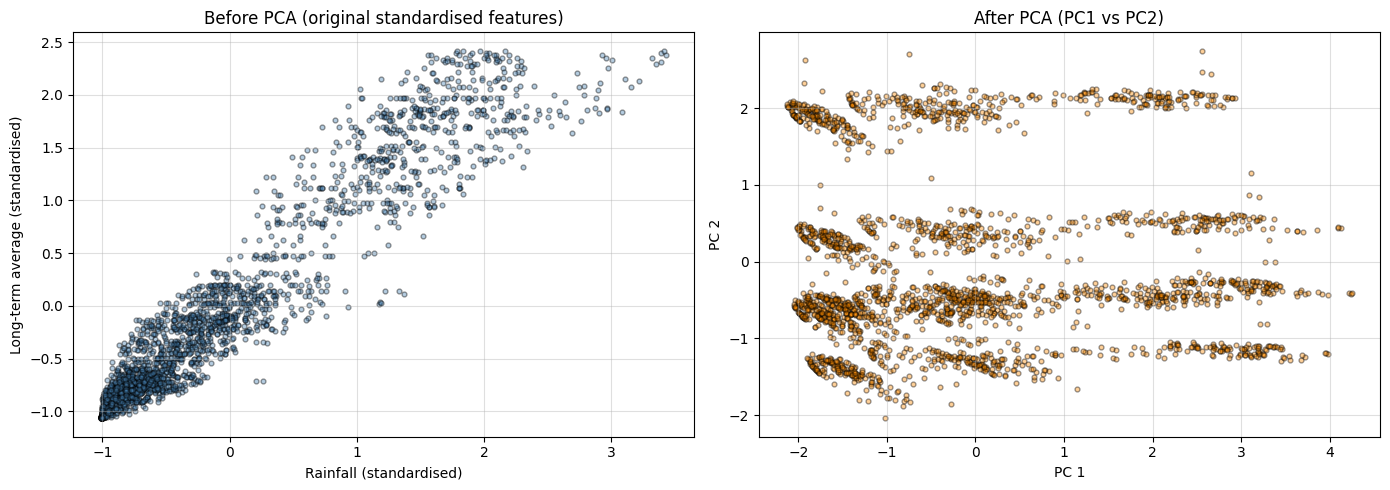

In [ ]:
idx = {c: i for i, c in enumerate(selected_columns)}
fx, fy = idx['rainfall'], idx['rainfall_long_term_average']

X_pc = X_std @ sorted_eigenvectors[:, :2]   # project onto first 2 PCs for plotting

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(X_std[:, fx], X_std[:, fy], alpha=0.4, s=12, color='steelblue', edgecolors='k')
axes[0].set(title="Before PCA (original standardised features)",
            xlabel="Rainfall (standardised)", ylabel="Long-term average (standardised)")
axes[0].grid(alpha=0.4)

axes[1].scatter(X_pc[:, 0], X_pc[:, 1], alpha=0.4, s=12, color='darkorange', edgecolors='k')
axes[1].set(title="After PCA (PC1 vs PC2)", xlabel="PC 1", ylabel="PC 2")
axes[1].grid(alpha=0.4)
plt.tight_layout(); plt.show()

1.**Interpretation of the before and after PCA plots.**
The left plot shows rainfall against its long-term average,the points spread out diagonally because rainy periods are usually above their normal level. After PCA, the same points are rotated so that PC1 points where the data spreads the most and PC2 the second most. The new axes are mixes of all seven features, not single measurements.
2. **Why 5 components, and the tradeoff.**
We kept 5 components because that is the smallest number that explains at least 90% of the variance (we reach ~96%). This drops PC6 and PC7, which together hold only about 4% of the information. The tradeoff is losing a little detail to get a simpler, cleaner dataset. Fewer than 5 would lose useful signal, and keeping all 7 would make PCA pointless.
3. **What information is lost.**
The dropped components mostly carry the small difference between actual rainfall and its long-term average, `rainfall_anomaly_pct` already captures this. For uses like planting-season planning in Rwanda, two records with the same anomaly but slightly different rainfall gaps would look identical.

### Optimise performance & handle large datasets
A second implementation computes PCA via **SVD on the centred data** instead of
forming the covariance matrix. SVD never squares the condition number, so it is
numerically more stable for ill-conditioned or near-collinear features.
Covariance + `eigh` is faster when there are many more rows than columns, since the covariance matrix stays small (p x p). The two methods are
verified equivalent, then benchmarked - which one wins depends on the shape of the data.

In [ ]:
import time

def pca_eig(X):
    """PCA via covariance + symmetric eigendecomposition."""
    n = X.shape[0]
    cov = (X.T @ X) / (n - 1)
    vals, vecs = np.linalg.eigh(cov)
    order = np.argsort(vals)[::-1]
    return vals[order], vecs[:, order]

def pca_svd(X):
    """PCA via SVD on centred data (no covariance matrix formed)."""
    n = X.shape[0]
    U, S, Vt = np.linalg.svd(X, full_matrices=False)
    eigvals = (S ** 2) / (n - 1)     # eigenvalues of the covariance matrix
    return eigvals, Vt.T             # columns of Vt.T are the principal axes

# Correctness: SVD must reproduce the eigenvalues from the eig route
svd_vals, _ = pca_svd(X_std)
print("eig vs svd eigenvalues match:", np.allclose(sorted_eigenvalues, svd_vals))

# Benchmark on a larger synthetic matrix (same number of columns)
big = np.repeat(X_std, 50, axis=0) + np.random.normal(0, 1e-6, (X_std.shape[0] * 50, X_std.shape[1]))
print("Benchmark matrix:", big.shape)

t0 = time.perf_counter(); pca_eig(big); t_eig = time.perf_counter() - t0
t0 = time.perf_counter(); pca_svd(big); t_svd = time.perf_counter() - t0
print(f"Covariance + eigh : {t_eig*1000:7.2f} ms")
print(f"SVD               : {t_svd*1000:7.2f} ms")

eig vs svd eigenvalues match: True
Benchmark matrix: (119250, 7)
Covariance + eigh :    3.06 ms
SVD               :   18.73 ms
